Part 3: PCA + K-Means

sklearn has a digits dataset. Perform PCA on that to reduce the features down to features that would explain most of the variance. You need to find some sweet spot for the number of the features here. Then perform K-means clustering on this to cluster the images. Each cluster will most probably correspond to a digit.


Also, do you people how to make pipelines? Try to use this in part 3. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
filterwarnings('ignore')
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [2]:
df = load_digits()
df = pd.DataFrame(data=df.data, columns=df.feature_names)
df_labelled = df.copy()
df_labelled['target'] = load_digits().target


In [3]:
df.shape

(1797, 64)

In [ ]:
X = df.copy()
y = df_labelled['target']

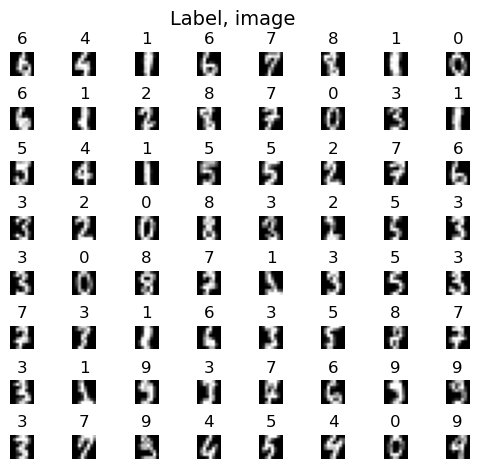

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(5,5))
fig.tight_layout(pad=0.13,rect=[0, 0.03, 1, 0.91])


for i,ax in enumerate(axes.flat):

    random_index = np.random.randint(m)

    X_random_reshaped = X.iloc[random_index].values.reshape((8,8))

    ax.imshow(X_random_reshaped, cmap='gray')

    ax.set_title(y[random_index])
    ax.set_axis_off()
    fig.suptitle("Label, image", fontsize=14)

plt.show()

In [6]:
df.isnull().sum().sum()

0

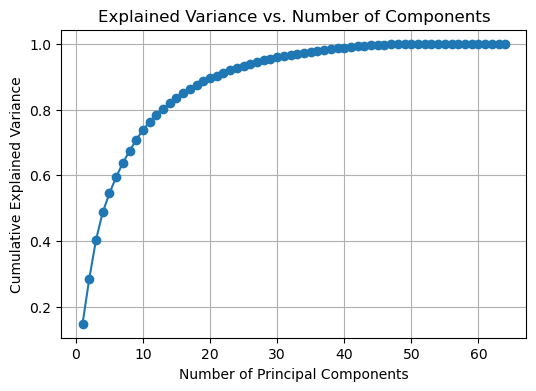

In [ ]:
pca = PCA()
pca.fit(X)


explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.grid(True)
plt.show()

In [ ]:
n_components = np.argmax(explained_variance >= 0.90) + 1
print(f"Optimal number of components: {n_components}")

Optimal number of components: 21


In [ ]:
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X)

kmeans = KMeans(n_clusters=10, random_state=42)
kmeans.fit(X_pca)

cluster_labels = kmeans.predict(X_pca)

print("Cluster labels:", cluster_labels)


Cluster labels: [3 2 6 ... 6 9 6]


  File "c:\Users\bhada\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\bhada\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\bhada\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\bhada\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


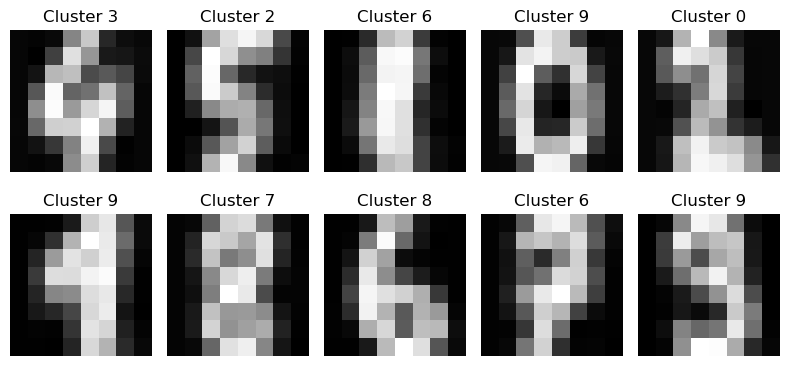

In [ ]:
centers_original = pca.inverse_transform(kmeans.cluster_centers_)

fig, axes = plt.subplots(2,5, figsize=(8, 4))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(centers_original[i].reshape(8, 8), cmap='gray')
    axes[i].set_title(f'Cluster {cluster_labels[i]}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [11]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, homogeneity_completeness_v_measure

true = df_labelled['target']
pred = cluster_labels

# 1. ARI
ari = adjusted_rand_score(true, pred)

# 2. NMI
nmi = normalized_mutual_info_score(true, pred)

# 3. Homogeneity, completeness, v-measure
h, c, v = homogeneity_completeness_v_measure(true, pred)

print(f"ARI: {ari:.3f}")
print(f"NMI: {nmi:.3f}")
print(f"Homogeneity: {h:.3f}, Completeness: {c:.3f}, V-measure: {v:.3f}")


ARI: 0.647
NMI: 0.742
Homogeneity: 0.732, Completeness: 0.753, V-measure: 0.742


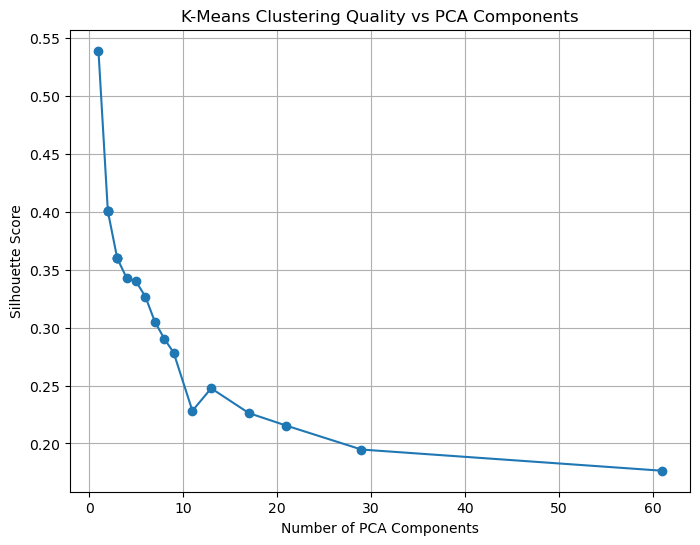

In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []
components_range = []
x_ticks = []
for i in range(10,101,5):
    n_components = np.argmax(explained_variance >= (i/100)) + 1
    components_range.append(n_components)
    x_ticks.append(i/100)

for n in components_range:
    pca = PCA(n_components=n)
    X_pca = pca.fit_transform(X)
    kmeans = KMeans(n_clusters=10, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

plt.figure(figsize=(8, 6))
plt.plot(components_range, scores, marker='o')
plt.xlabel('Number of PCA Components')
plt.ylabel('Silhouette Score')
plt.title('K-Means Clustering Quality vs PCA Components')
plt.grid(True)
plt.show()

In [18]:
for i in range(len(scores)):
    print(f'{x_ticks[i]}, Components: {components_range[i]}, Silhouette Score: {scores[i]:.4f}')

0.1, Components: 1, Silhouette Score: 0.5389
0.15, Components: 2, Silhouette Score: 0.4004
0.2, Components: 2, Silhouette Score: 0.4004
0.25, Components: 2, Silhouette Score: 0.4004
0.3, Components: 3, Silhouette Score: 0.3597
0.35, Components: 3, Silhouette Score: 0.3597
0.4, Components: 3, Silhouette Score: 0.3597
0.45, Components: 4, Silhouette Score: 0.3428
0.5, Components: 5, Silhouette Score: 0.3398
0.55, Components: 6, Silhouette Score: 0.3266
0.6, Components: 7, Silhouette Score: 0.3051
0.65, Components: 8, Silhouette Score: 0.2905
0.7, Components: 9, Silhouette Score: 0.2784
0.75, Components: 11, Silhouette Score: 0.2282
0.8, Components: 13, Silhouette Score: 0.2476
0.85, Components: 17, Silhouette Score: 0.2263
0.9, Components: 21, Silhouette Score: 0.2154
0.95, Components: 29, Silhouette Score: 0.1948
1.0, Components: 61, Silhouette Score: 0.1765
